In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

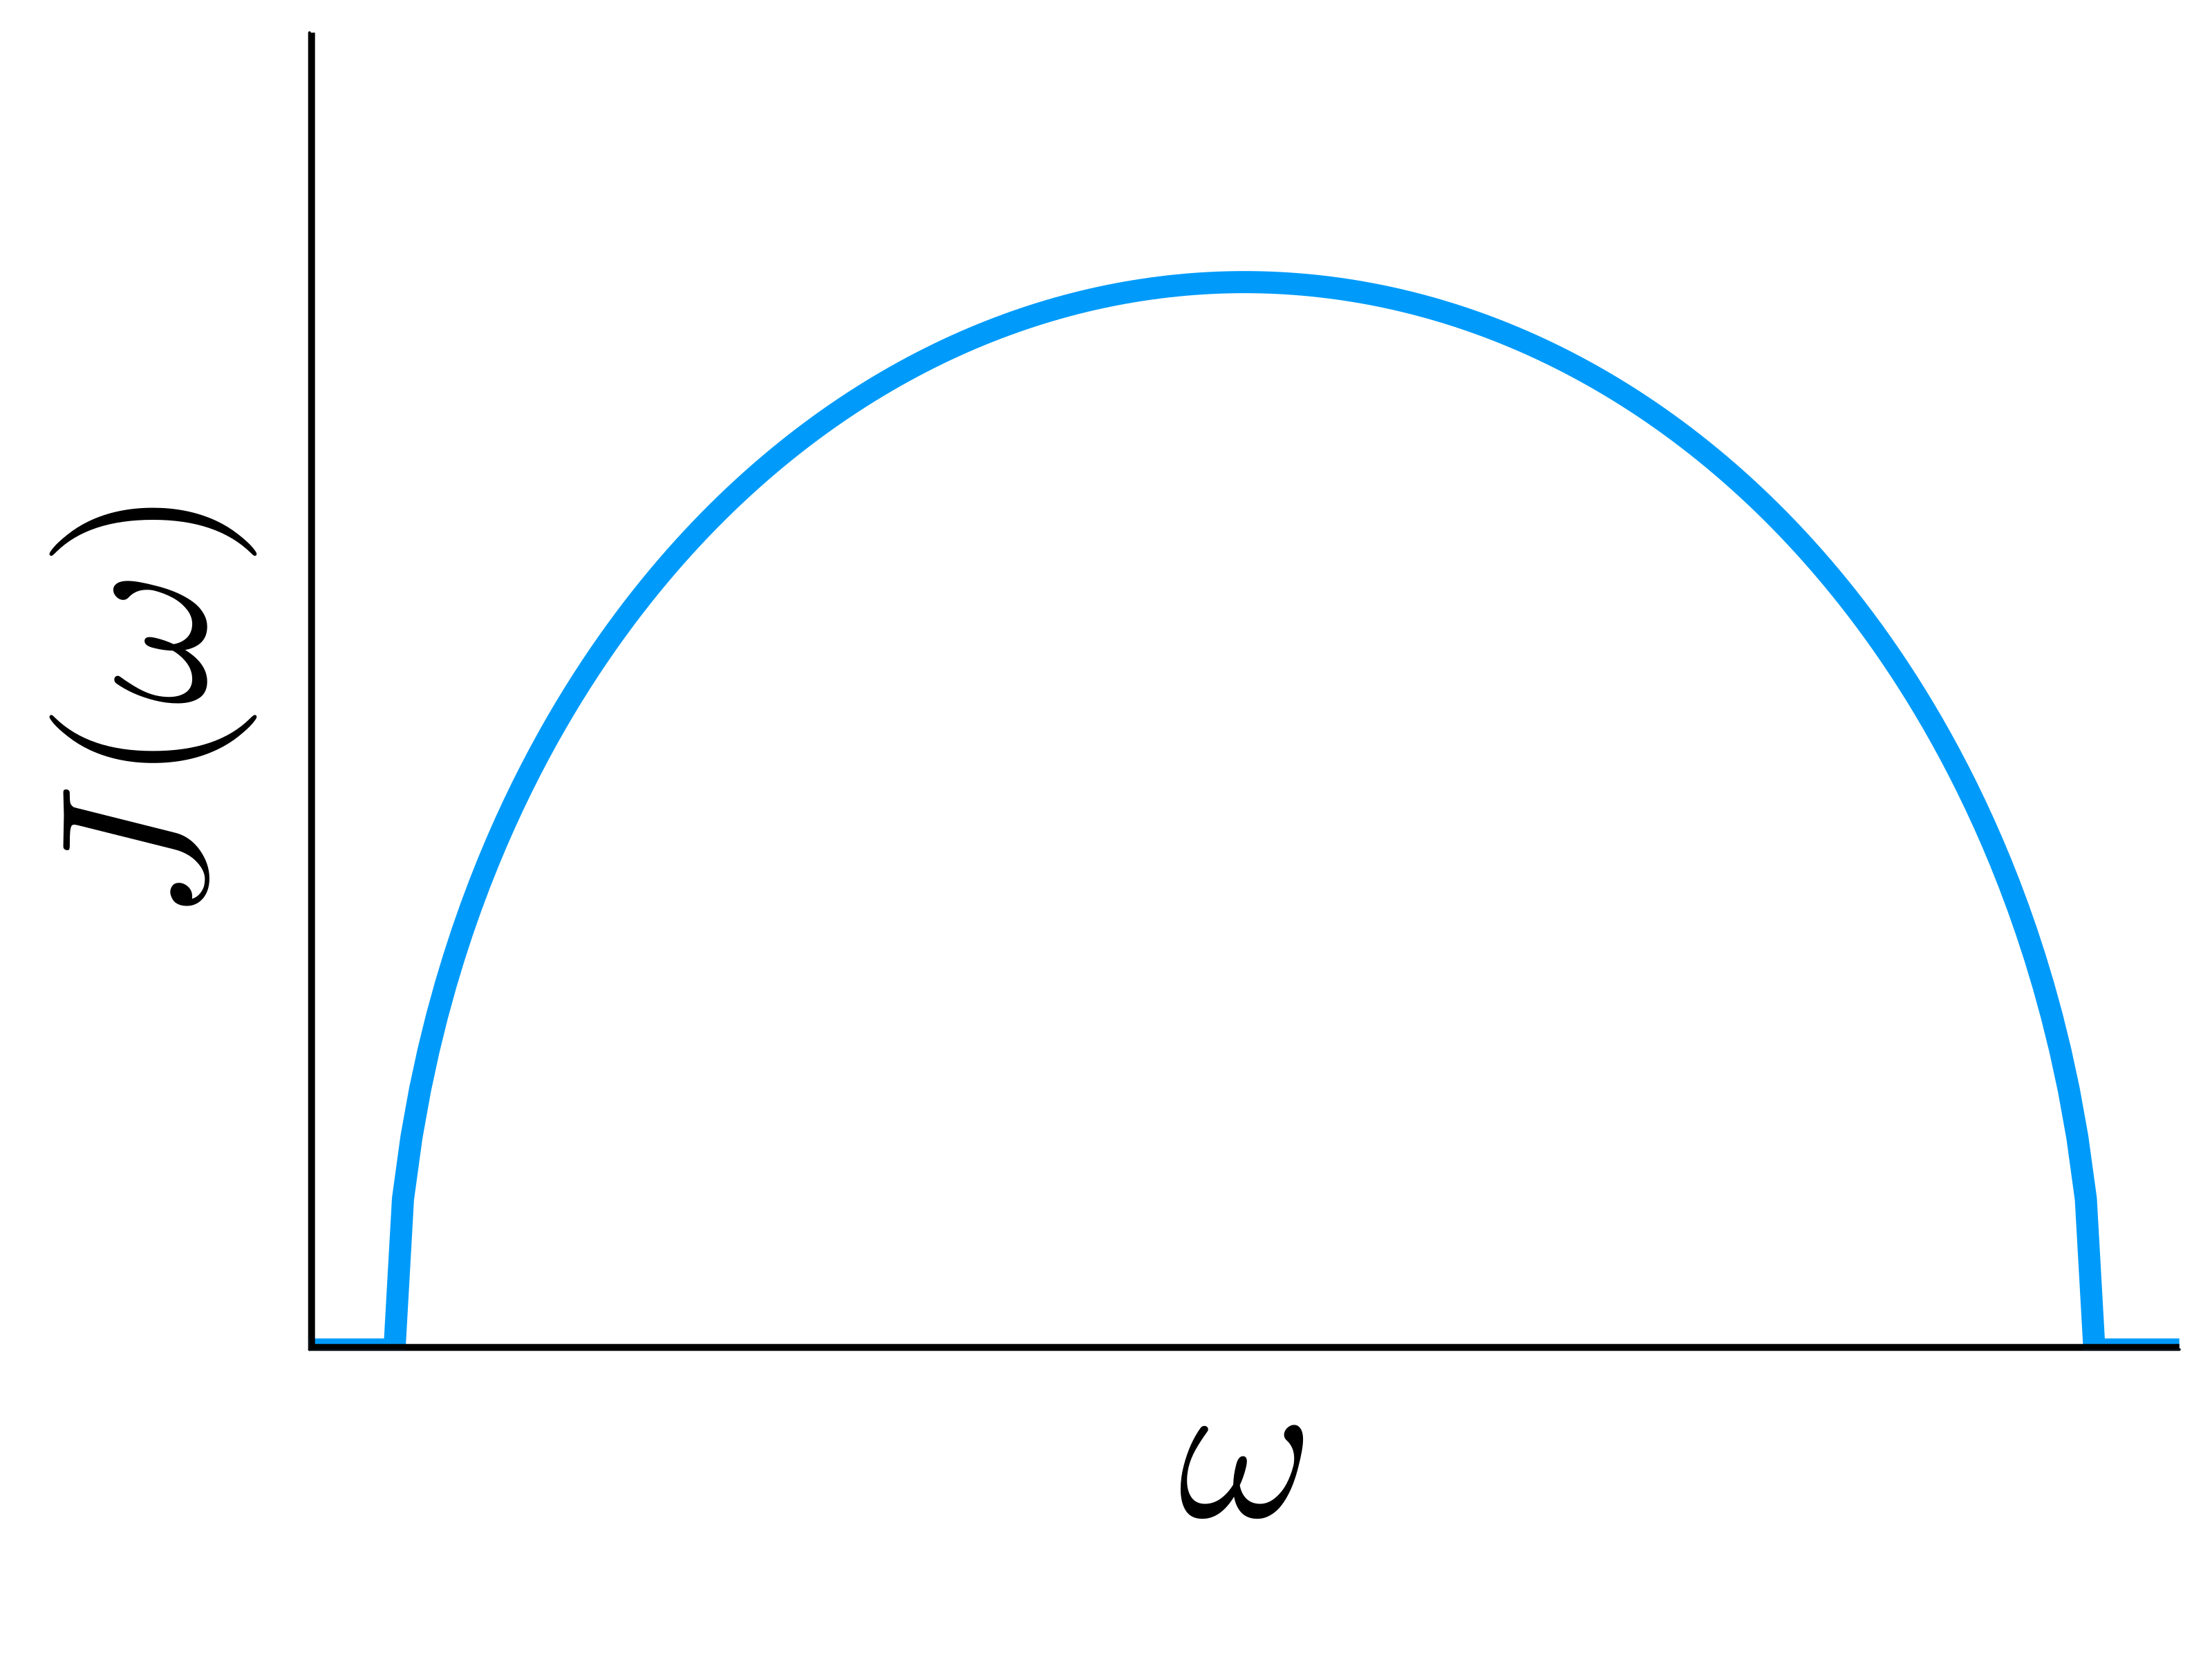

"c:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\ellipse.svg"

In [93]:
P = set_P()
mu = 0.1
beta = 20.0
gamma = 1.0
T = 50.0

P.spec_fun = "ellipse"
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

xvals = collect(-1.1:0.01:1.1)
J = spectral_function(P,"L")
yvals = [J(x) for x in xvals]

p = plot(xvals, yvals,
         xlabel="\$\\omega\$", ylabel="\$J(\\omega)\$", xlims=(-1.1,1.1), ylims=(0,0.25),
         legend=false, xticks=false, yticks=false, lw=8, dpi=400, size=(800,600), 
         guidefontsize=50, left_margin=10mm, bottom_margin=10mm)
vline!(p, [-1.1], lw=4, c=:black)
hline!(p, [0.0], lw=4, c=:black)
display(p)

savefig(p, "PosterPlots\\ellipse.svg")

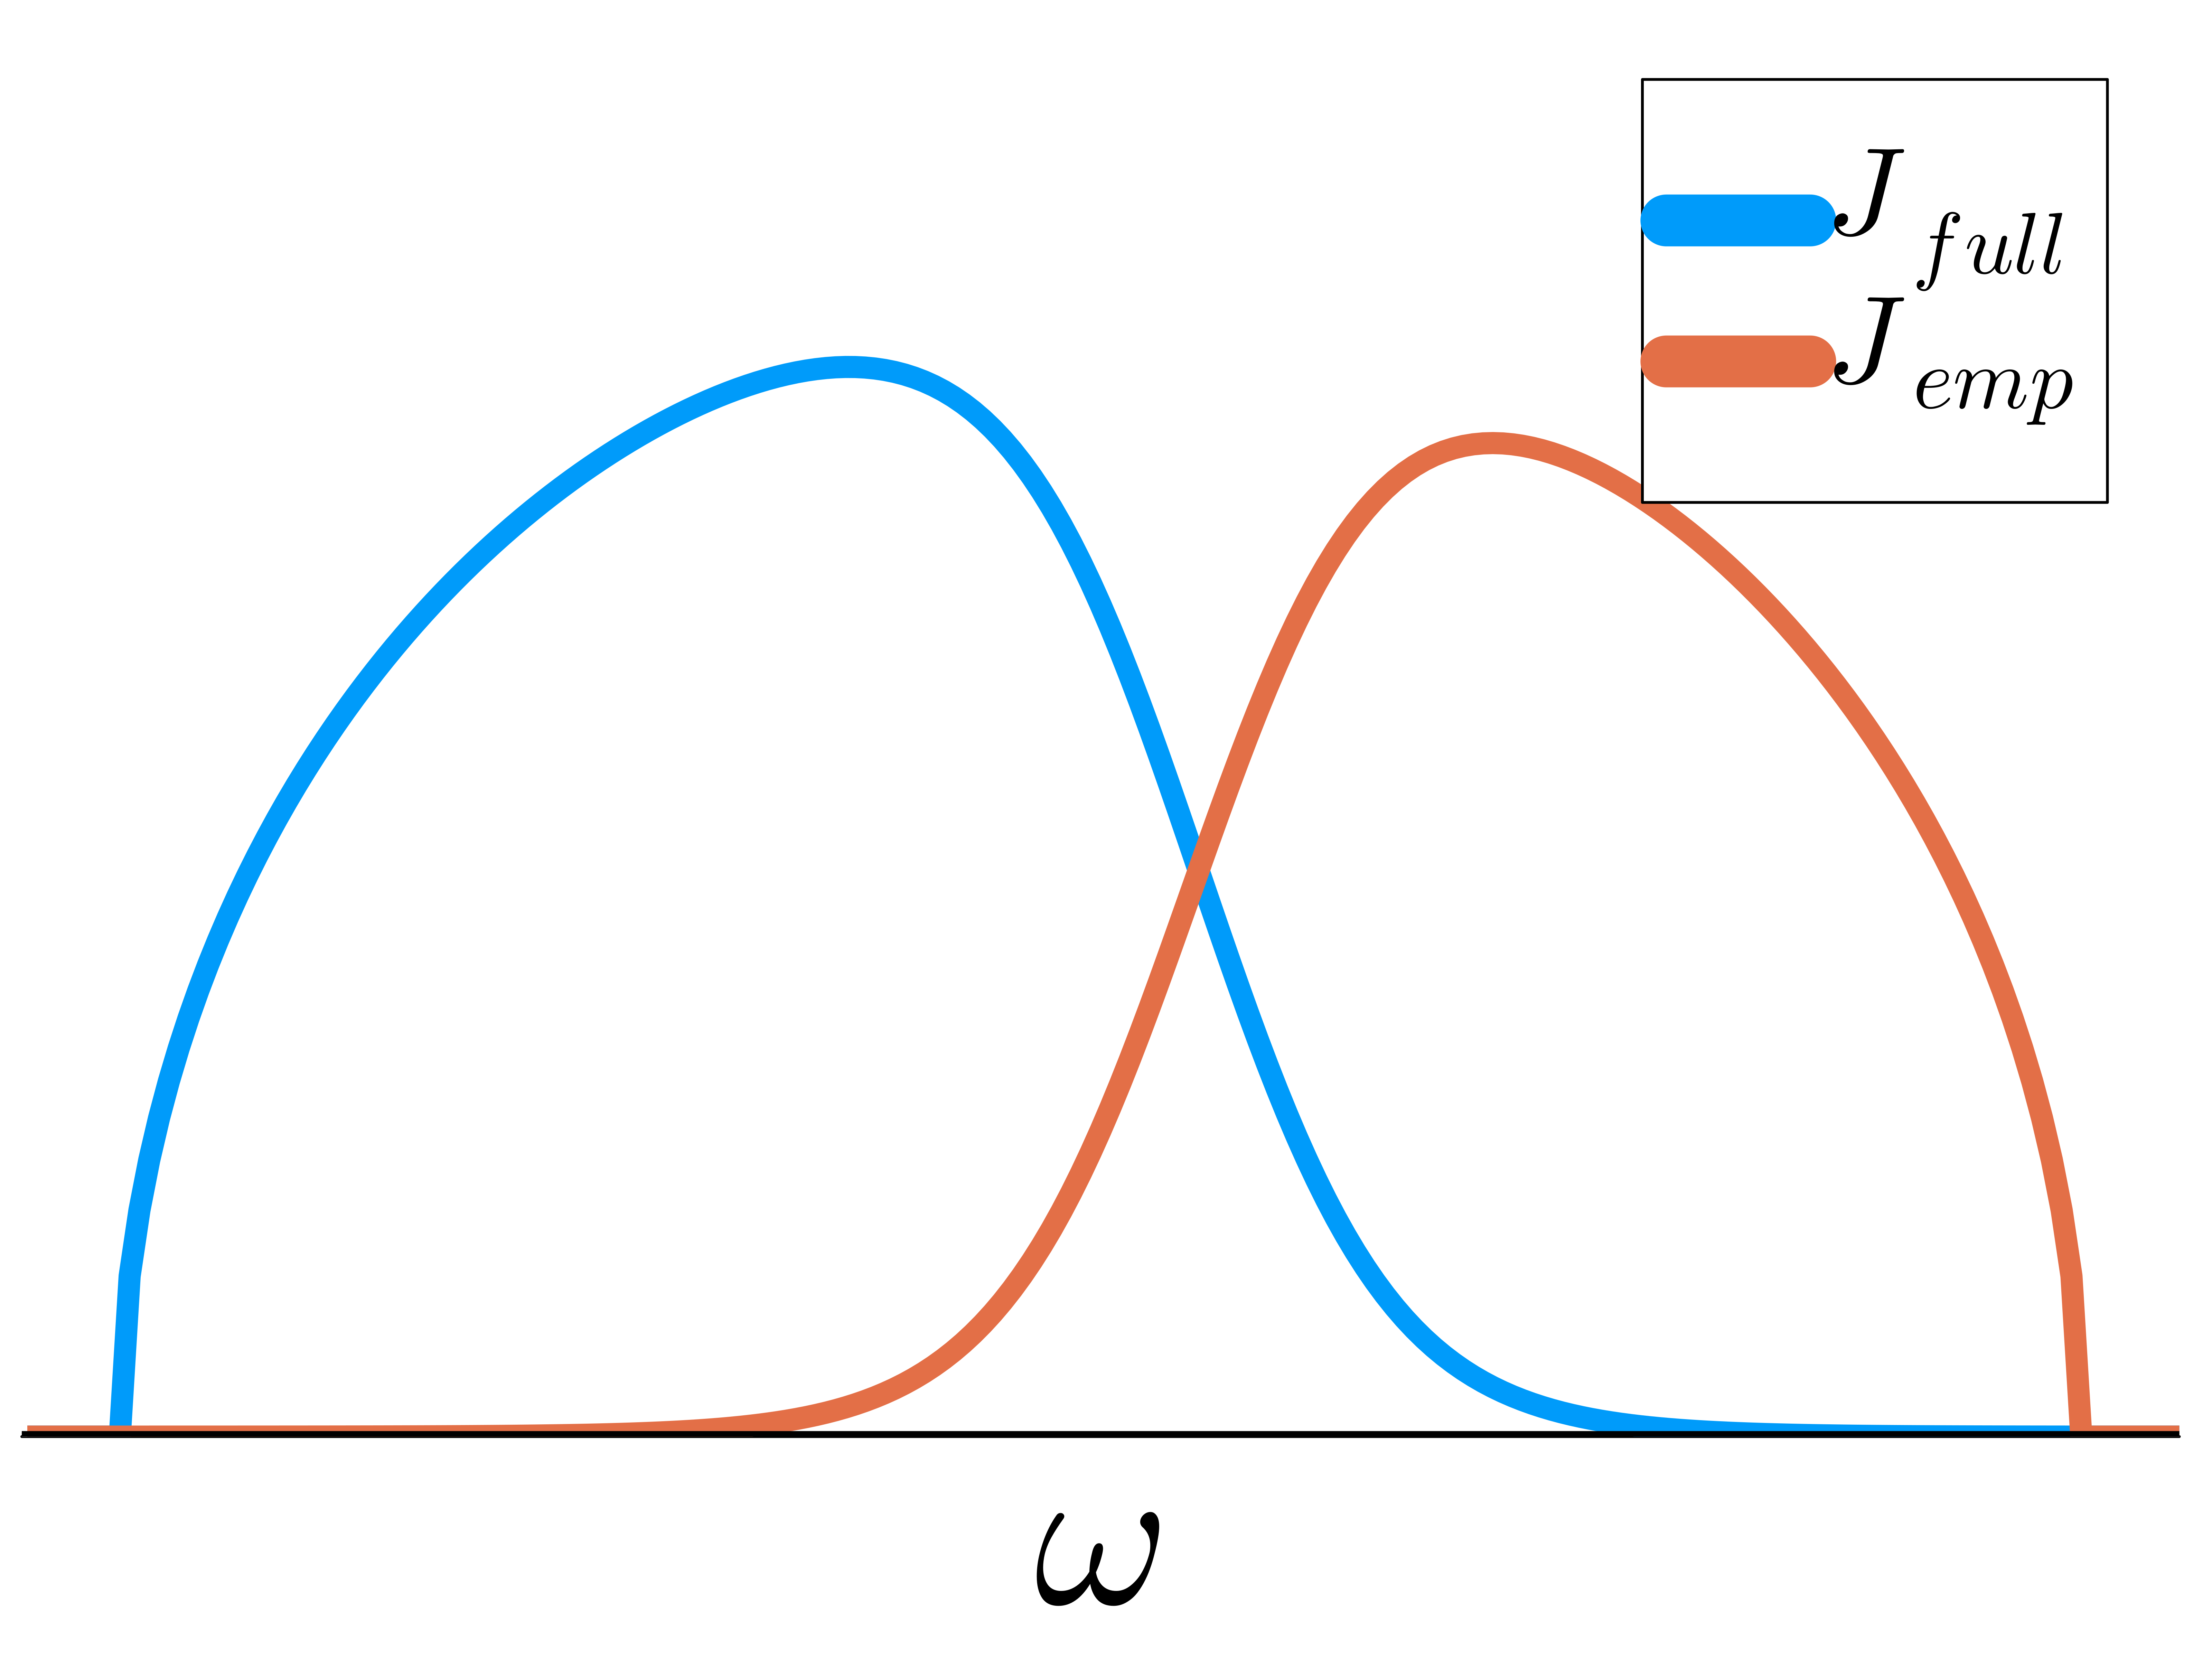

"c:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\thermofield.svg"

In [94]:
J1, J2 = thermofield_double(J, 10.0, 0.1)
yvals1 = [J1(x) for x in xvals]
yvals2 = [J2(x) for x in xvals]
p = plot(xvals, yvals1, xlabel="\$\\omega\$", xlims=(-1.1,1.1), ylims=(0,0.25), yaxis=false,
         label="\$J_{full}\$", xticks=false, yticks=false, lw=8, dpi=800, size=(800,600), 
         guidefontsize=50, left_margin=0mm, bottom_margin=2mm, legendfontsize=30)
plot!(p, xvals, yvals2, label="\$J_{emp}\$", lw=8)

vline!(p, [-1.1], lw=4, c=:white, label="")
hline!(p, [0.0], lw=4, c=:black, label="")
display(p)

savefig(p, "PosterPlots\\thermofield.svg")

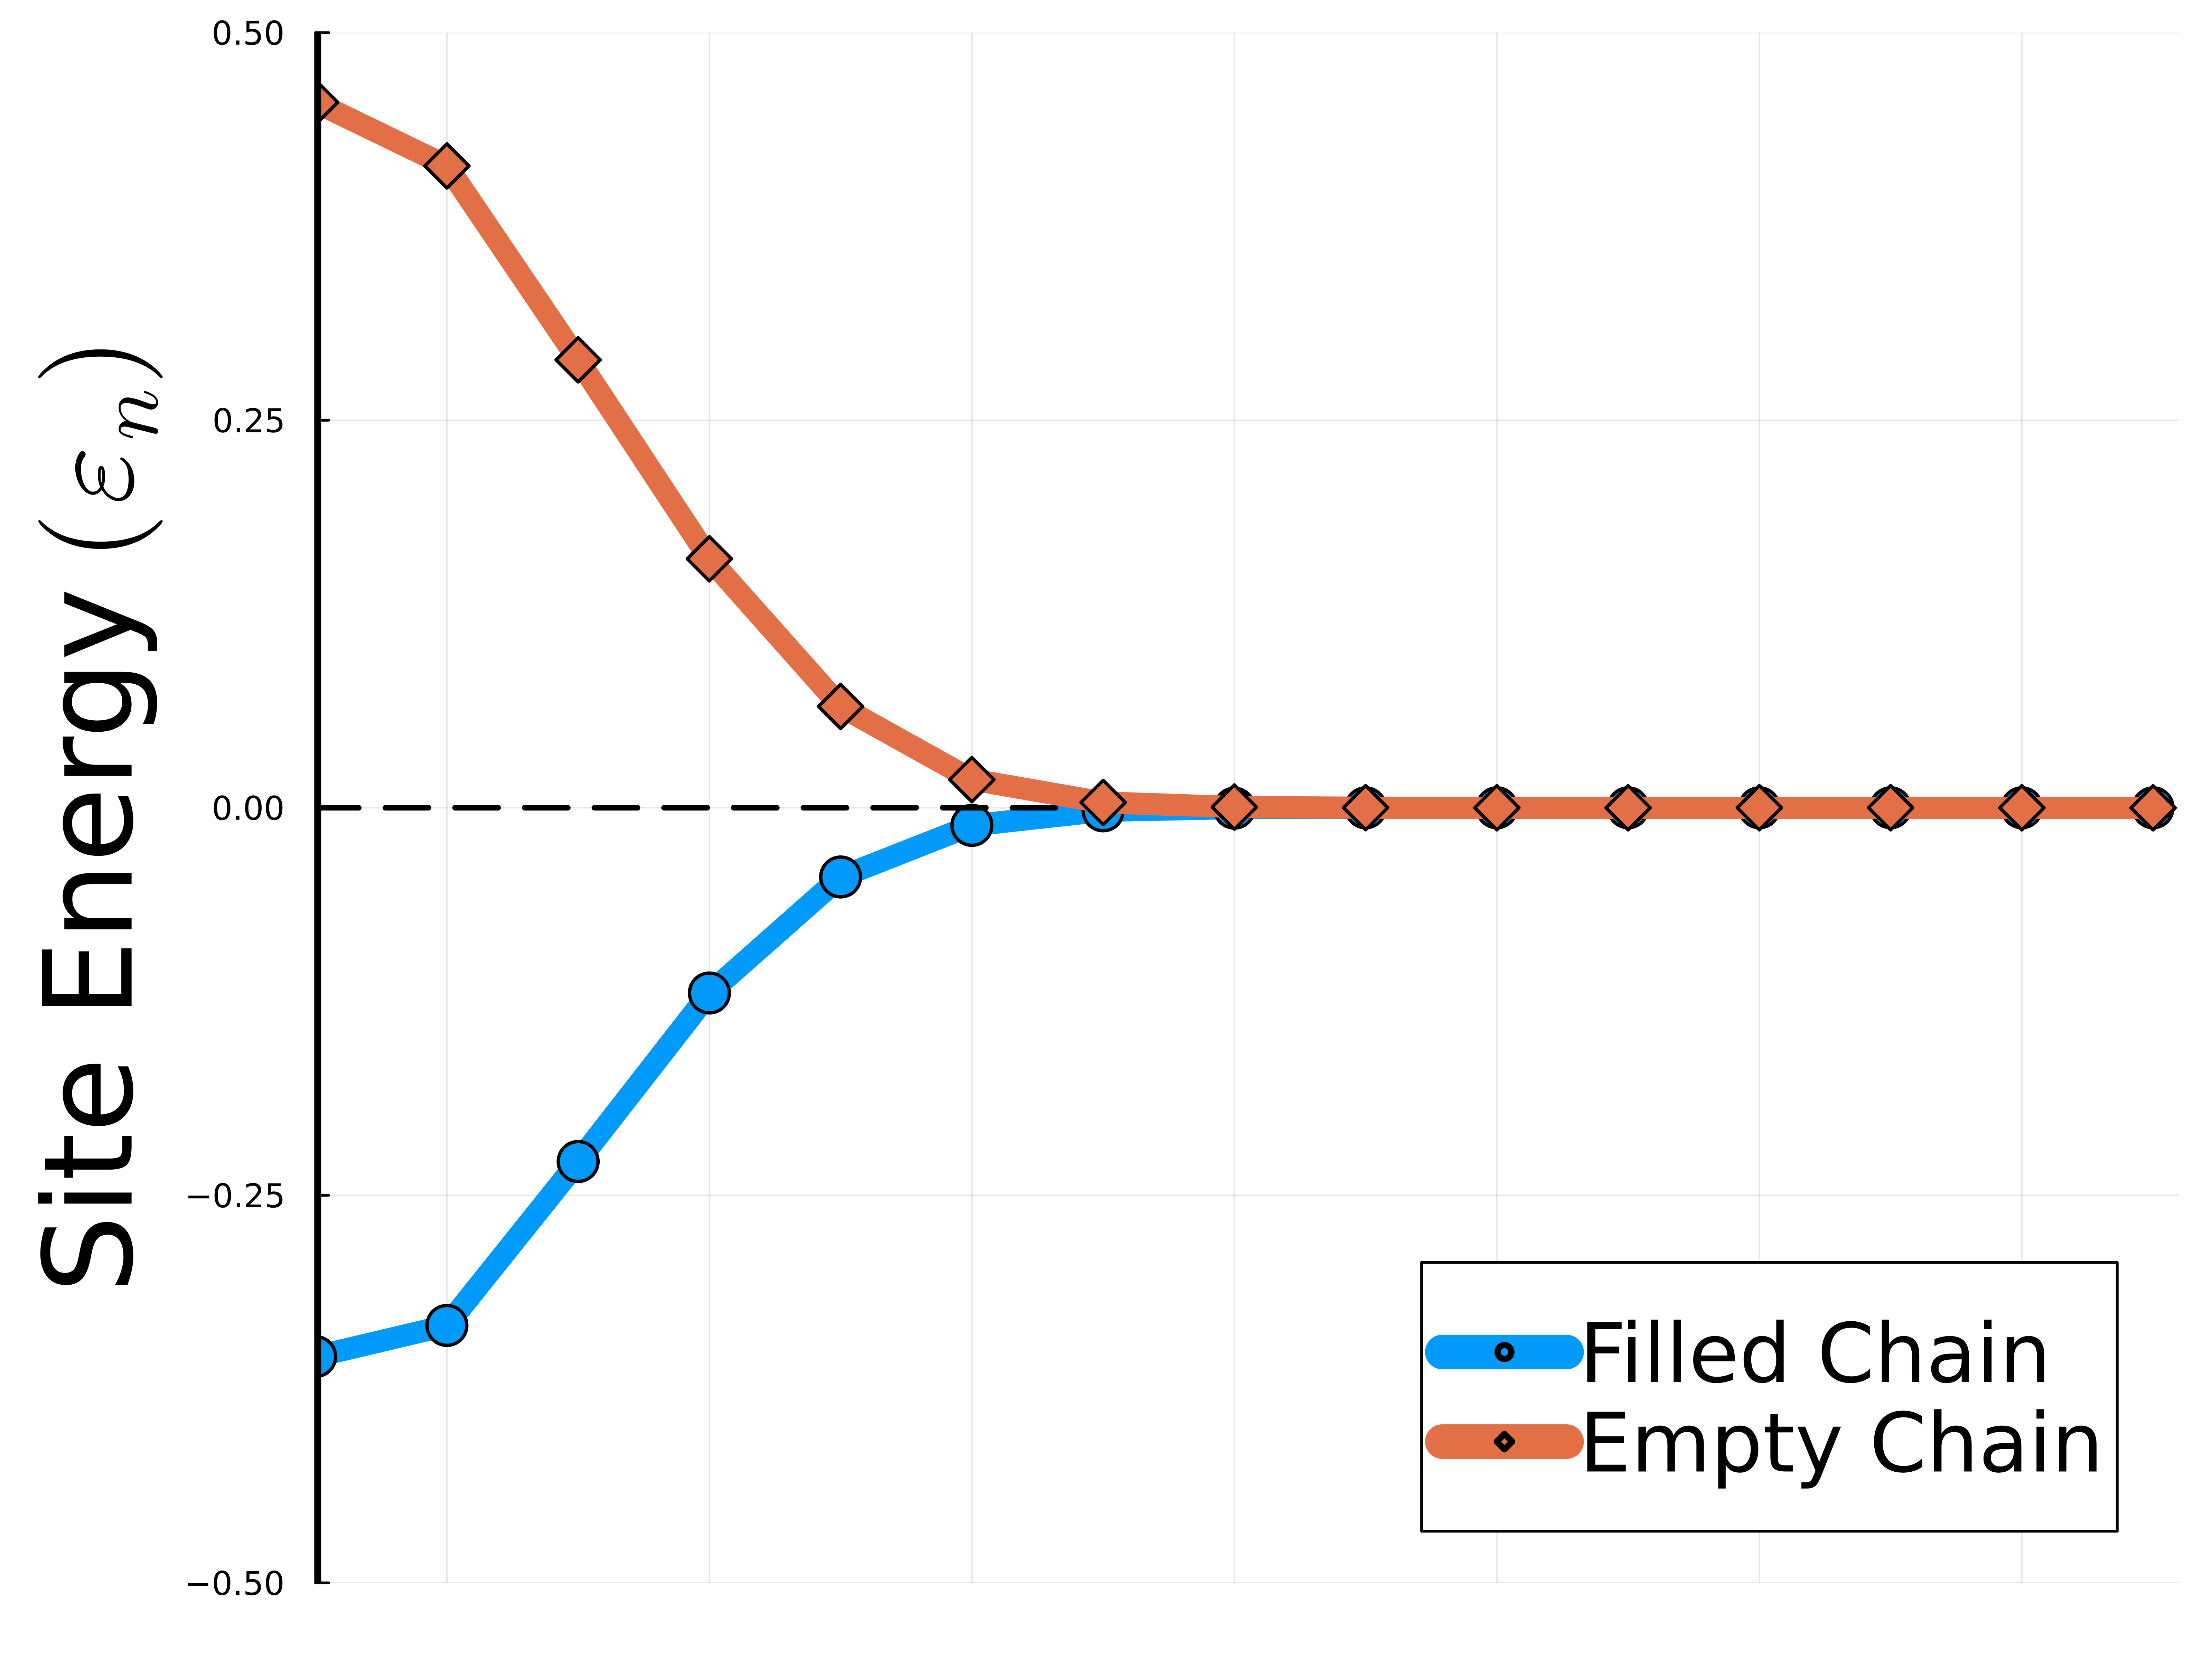

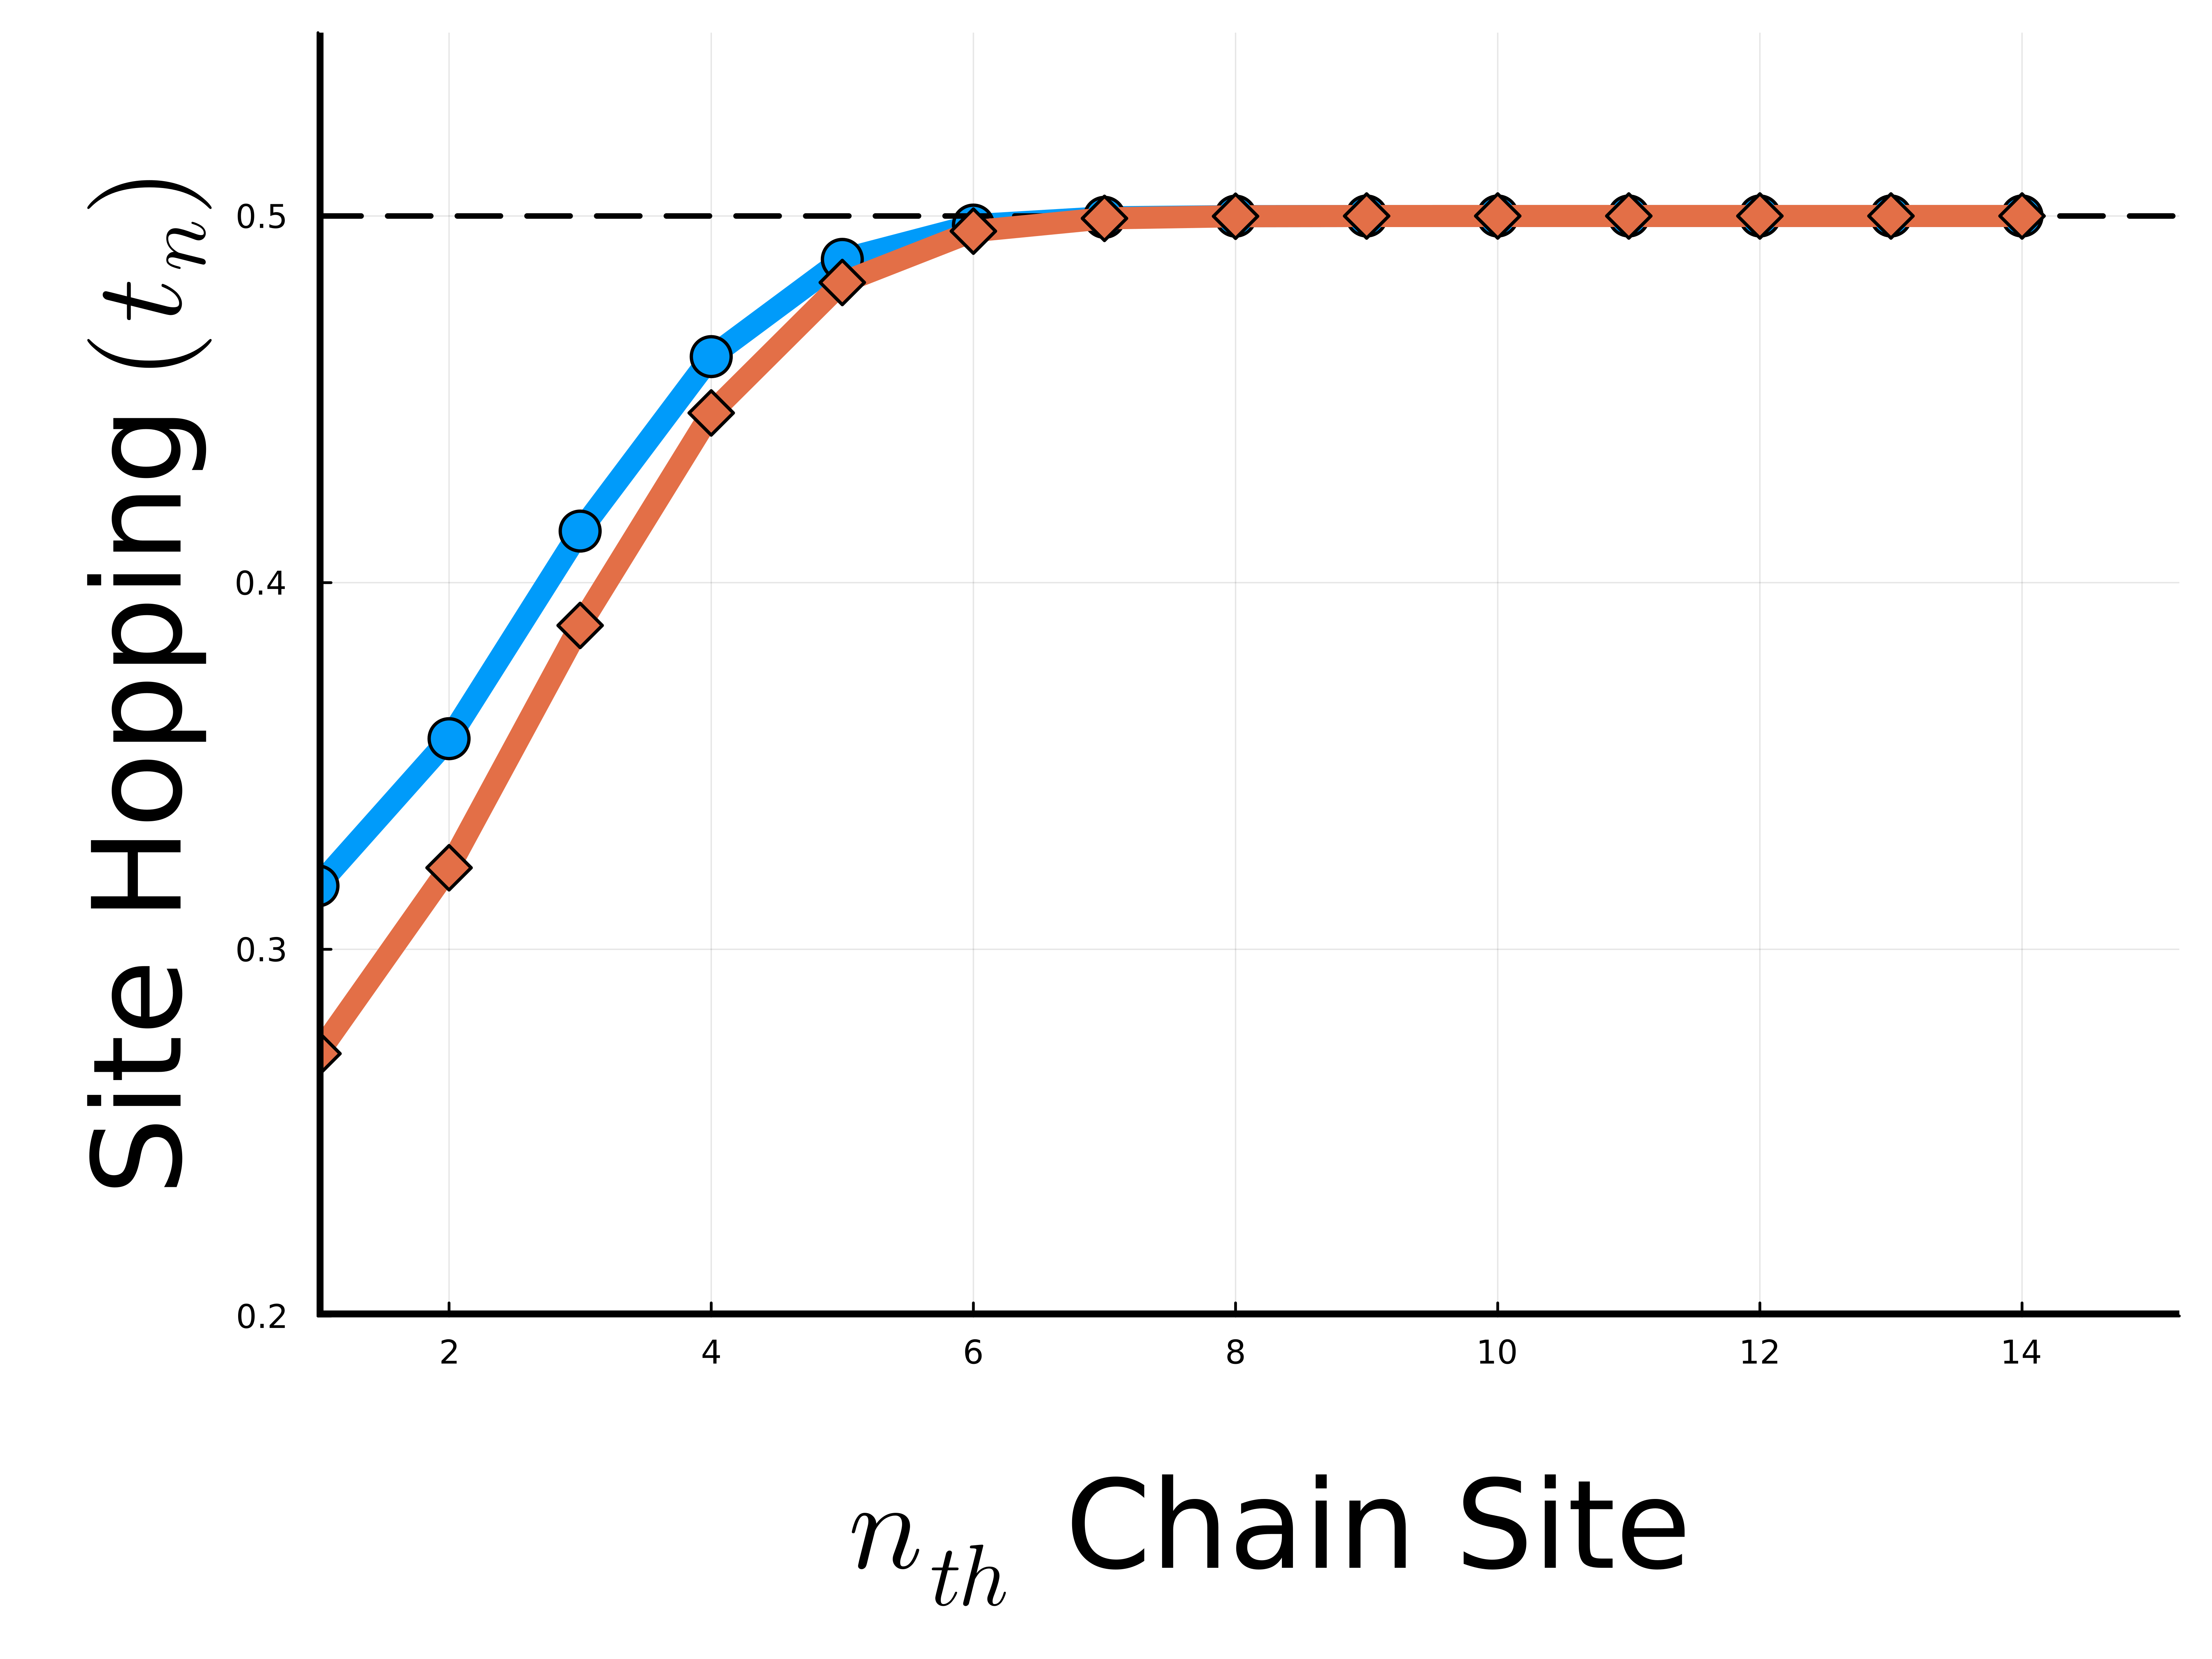

"c:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\hoppings.svg"

In [95]:
E1, t1 = chain_map(J1, 15, 1.0, P)
E2, t2 = chain_map(J2, 15, 1.0, P)
Nvals = collect(1:15)
p1 = plot(Nvals, E1, ylabel="Site Energy \$(\\epsilon_n)\$", xaxis=false,
         label="Filled Chain", lw=8, dpi=800, size=(800,600), xlims=(1,15.2), ylims=(-0.5,0.5), markershape=:circle, markersize=8,
         guidefontsize=30, left_margin=5mm, bottom_margin=0mm, legend=:bottomright, legendfontsize=20)
hline!(p1, [0.0], lw=2, c=:black, label="", linestyle=:dash)
plot!(p1, E2, label="Empty Chain", lw=8, markershape=:diamond, markersize=8, c=2)
vline!(p1, [1.0], lw=4, c=:black, label="")

display(p1)
savefig(p1, "PosterPlots\\energies.svg")

p2 = plot(1:14, t1[2:end], xlabel="\n \$n_{th}\$ Chain Site", ylabel="Site Hopping \$(t_n)\$",
         label="Filled Chain", lw=8, dpi=800, size=(800,600), xlims=(1,15.2), ylims=(0.2,0.55), markershape=:circle, markersize=8,
         guidefontsize=30, left_margin=9.5mm, bottom_margin=5mm, legend=false, legendfontsize=20)
hline!(p2, [0.5], lw=2, linestyle=:dash, c=:black, label="")
plot!(p2, 1:14, t2[2:end], label="Empty Chain", lw=8, c=2, markershape=:diamond, markersize=8)
vline!(p2, [1.0], lw=4, c=:black, label="")
hline!(p2, [0.2], lw=4, c=:black, label="")
display(p2)
savefig(p2, "PosterPlots\\hoppings.svg")